# Image Reduction

    Created: Zachary Lane, June 2024
    Edited: Zachary Lane, July 2024
    Last Edited: C.Clare Worley, July 2024
    

This notebook is aimed at teaching students about image reduction.

Work your way through the notebook, **reading each code cell carefully before running it**. This is a live document, all the cells can easily be edited, and re-run any time you wish. Ask questions if you need to.

In [2]:
import os # A module for communicating with the operating system e.g. commands and files
import glob # A module for searching data files
import matplotlib.pyplot as plt # A plotting library
import numpy as np # Numerical Python, great for vectorised equations
import scipy # Scientific Python, great for algorithms and optimisation
import pandas as pd # DataFrames for organising data/tables
from astropy.io import fits # Astronomy Python for opening ".fits" files
from photutils.background import Background2D, MedianBackground # Fitting background surfaces to astronomical images
from copy import deepcopy # A module for copying objects
import warnings # To ignore our problems
warnings.filterwarnings('ignore', category=RuntimeWarning) #Shhhhh, ignore our problems


%matplotlib inline


### Image reduction formula

We will be reducing our images based on the following formula...

$$I_f^{} = \frac{I_r^{} - {\rm master}[D_I^{}]}{{\rm master}[{\rm cal.}(F_I^{} - D_F^{})]} - B$$

Where:

$I_f$ - Final (Science) image

$I_r$ - Raw image

$D_I$ - Dark taken with the same exposure time as the Raw image

$F_I$ - Flat taken with the same filter as the Raw image

$D_F$ - Dark taken with the same exposure time as the Flat

$B$ - Background level



# Task 1: File Management

We will be using sets of Raw images, Dark images (darks), and Flat images (flats) to generate final Science images.

The files we need are stored on the macdiarmid server in: ASTR211/2024_Lab_Files/Phot_Reduction_Lab/


Using your file browser, navigate to the folder (see General Lab Instructions to access mcdiarmid server) and visually inspect the contents.

The filenames appear to encode some useful information. Can you tell from the filename which files are darks, flats or raw images? We can use this information to organise our files. However, there is no guarantee that filenames contain all the information that you need.

Instead we should interrogate the headers (the metadata) of the FITS files.

Use the relevant lines of code in the 'File Organising' section from Lab 1 and from 'Lab 2 Part 1 - FITS file lab' to organise the files into the three lists of raw images, dark images and flat images following these steps:

1. Generate a list of ALL the files in: ASTR211/2024_Lab_Files/Phot_Reduction_Lab/ and print the list to screen. ('File Organising' section from Lab 1)
2. Open up the first FITS file and print the FITS information to the screen ('Lab 2 Part 1 - FITS file lab'), 
3. The metadata (keyword) that tells you the image type is "IMAGETYP" in the PRIMARY header. Print this value to screen for the  the single FITS file, e.g. hdul[0].header['IMAGETYP'].
2. Adapt your code into a For loop that loops through the full list of files and prints the 'IMAGETYP' keyword to the screen. What are the different image types? Discuss with a tutor.
3. Adapt your For loop to create: 
- a list of dark files
- a list of flat files
- a list of raw files

How many of each type do you have?



In [3]:

# Folders
folder = '//macdiarmid/ASTR211/2024_Lab_Files/Phot_Reduction_Lab/' # This is the direct folder with the files

# Goes through and finds each file in a designated folder

files = [folder + file for file in os.listdir(folder) if '.fit' in file]

print()
# Goes through and finds each file with a specific pattern in the folder, alternate method (puts in a list)
# This method is architecture dependent (e.g. the order for a MacOs M3 will be different to a Windows HP)
darks = []
flats = []
lights = []

files = glob.glob(folder + '*.fit*')
for file in files:
    hdul = fits.open(file)
    img_type = hdul[0].header['IMAGETYP']
    if img_type == "Dark Frame":
        print(hdul[0].header['EXPTIME'])
        darks.append(file)
    elif img_type == "Flat Field":
        flats.append(file)
    else:
        lights.append(file)
print(f"Darks: {len(darks)}")
print(darks)
print(f"Flats: {len(flats)}")
print(f"Lights: {len(lights)}")


15.0
15.0
15.0
60.0
60.0
60.0
Darks: 6
['//macdiarmid/ASTR211/2024_Lab_Files/Phot_Reduction_Lab\\Dark-0005_15.fit', '//macdiarmid/ASTR211/2024_Lab_Files/Phot_Reduction_Lab\\Dark-0006_15.fit', '//macdiarmid/ASTR211/2024_Lab_Files/Phot_Reduction_Lab\\Dark-0007_15.fit', '//macdiarmid/ASTR211/2024_Lab_Files/Phot_Reduction_Lab\\Darks-0001_60.fit', '//macdiarmid/ASTR211/2024_Lab_Files/Phot_Reduction_Lab\\Darks-0002_60.fit', '//macdiarmid/ASTR211/2024_Lab_Files/Phot_Reduction_Lab\\Darks-0003_60.fit']
Flats: 6
Lights: 10


# Task 2: Find the relevant raw images and associated calibration files

We are going to reduce the raw image files which have an exposure time of 60 seconds (s) and were observed in the "r" filter. 

How can you tell which filter was used and what the exposure time is? The filename does encode some of these but not all for every file. Instead we will extract this information from the PRIMARY header.

First, print the PRIMARY header to the screen. 

Can you find the "IMAGTYP" keyword?

What do you think are the keywords that tell you what the exposure time is, and what the filter is? Discuss with a tutor.

In [4]:
for file in lights:
    hdul = fits.open(file)
    header = hdul[0].header
    print(header)
    print("\n"* 3)

SIMPLE  =                    T                                                  BITPIX  =                   16 /8 unsigned int, 16 & 32 int, -32 & -64 real     NAXIS   =                    2 /number of axes                                  NAXIS1  =                 2048 /fastest changing axis                           NAXIS2  =                 2048 /next to fastest changing axis                   BSCALE  =   1.0000000000000000 /physical = BZERO + BSCALE*array_value           BZERO   =   32768.000000000000 /physical = BZERO + BSCALE*array_value           DATE-OBS= '2023-11-25T11:27:37.27' /YYYY-MM-DDThh:mm:ss observation, UT         EXPTIME =   60.000000000000000 /Exposure time in seconds                        EXPOSURE=   60.000000000000000 /Exposure time in seconds                        SET-TEMP=  -40.000000000000000 /CCD temperature setpoint in C                   CCD-TEMP=  -40.000000000000000 /CCD temperature at start of exposure in C       XPIXSZ  =   13.500000000000000 /Pixel Wi

You will now structure your files into the sets of data that you need for the reduction. Note also that all images used in this lab are all taken within a few days of each other. However, this is not always the case.

## File Structuring:
To reduce your raw images you need the following four lists of files:
1. raw images observed in the "r" filter with an exposure time of 60s
2. flats observed in the "r" filter with an exposure time of 15s
3. darks observed with the same same exposure time as the images
4. darks observed with the same exposure time as the flats

Follow these steps:
1. Copy your data organising code to the below cell
2. Adapt it to extract the values for the keywords for exposure time and filter
3. Save to pertinent lists the raw, flat and dark files that meet the above criteria

In [5]:
raws = lights
flats = flats
dark15 = []
dark60 = []

for dark in darks:
    hdul = fits.open(dark)
    header = hdul[0].header
    print(header["EXPTIME"])
    if header["EXPTIME"] == 60:
        dark60.append(dark)
    else:
        dark15.append(dark)
print(len(dark15))
print(len(dark60))

15.0
15.0
15.0
60.0
60.0
60.0
3
3


When you have your lists,  *confirm they are correct with the tutor*.

For future work you can combine this file structuring into the data organising of Task 1.


# Task 3: Creating the Master Darks

We will now start the process to reduce the raw images. The first step is to create a master dark for each exposure time from our two sets of darks.

$${\rm master}[D_X^{}]$$

Below is a general example of how to do this using a simple method. 

In [6]:
darks_data = []
list_dark_files = darks
for dark_file in list_dark_files:
    hdul = fits.open(dark_file)
    darks_data.append(hdul[0].data) # Append the data to the list
    hdul.close()

master_dark = np.median(darks_data, axis=0) # Median combine the darks

## Task 3.1: Creating Master Dark for Flats

Adapt the example code to create your master dark associated with your flats e.g. exposure time of 15s. 

Change the variable names to match what you have used.

In [7]:
darks_data = []
list_dark_files = dark15
for dark_file in list_dark_files:
    hdul = fits.open(dark_file)
    darks_data.append(hdul[0].data) # Append the data to the list
    hdul.close()

master_dark15 = np.median(darks_data, axis=0) # Median combine the darks

Why do we use a median? Why not a mean? Discuss with a tutor.


## Task 3.2: Creating Master Dark for Images

Now use a copy of your code and modify it to create a master dark associated with your images e.g. exposure time of 60s.

In [8]:
darks_data = []
list_dark_files = dark60
for dark_file in list_dark_files:
    hdul = fits.open(dark_file)
    darks_data.append(hdul[0].data) # Append the data to the list
    hdul.close()

master_dark60 = np.median(darks_data, axis=0) # Median combine the darks
print(master_dark.dtype)

float64


Plot each of your master darks. (Look in Lab 1 or Lab 2 for useful plotting code).

Inspect both and consider the following questions:
1. What features are in both?
2. What are the features?
3. What is different between the master darks? Discuss with a tutor.



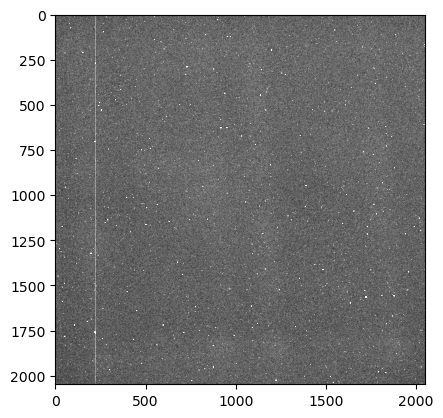

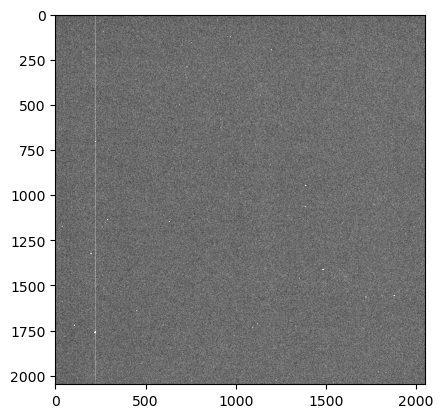

In [9]:
plt.imshow(master_dark60, vmin = np.nanpercentile(master_dark60, 5), vmax = np.nanpercentile(master_dark60, 99), cmap = 'gray')
plt.figure()
plt.imshow(master_dark15, vmin = np.nanpercentile(master_dark15, 5), vmax = np.nanpercentile(master_dark15, 99), cmap = 'gray')

# Task 4: Creating the Master Flat

Creating a master flat is a little more complex. 

First we must subtract the master dark of the same exposure time from each individual flat to generate a set of 'master dark-subtracted' flats or 'calibrated' flats. In this simplified example we have only one master dark for the flats, but occasionally you will have multiple master darks. 

We then need to check the signal of the calibrated flats. Ideally we want a median count across the pixels to be above 24000 and below 45000. This maximises the signal without resulting in saturated pixels.

Follow these steps to create your master flat:
1. Subtract the master dark for flats from each individual flat to create a set of calibrated flats.
2. Calculate the median count of each calibrated flat. 
3. Determine how many calibrated flats have a median count between 24000 and 45000.
4. Reject any calibrated flats that are below 24000 or above 45000.
3. Divide each accepted calibrated flat by its median count to generate a normalised, calibrated flat.
5. With the resulting set of normalised, calibrated flats generate the master flat (See Task 3 example for master dark)
6. Plot the master flat, what features do you notice? How does it compare to an individual flat? What if you do not reject any flats, how does the master flat change? Discuss these with a tutor.


Hint 1: Test steps 1-3 using one flat to begin with. Then you can expand it into a For loop.

Hint 2: Plot each stage to see how the flat is changing. What number can you use to assess it changing?



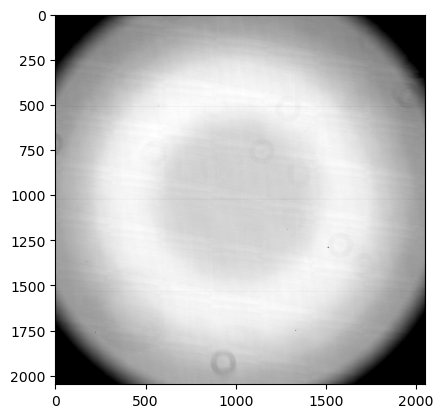

In [10]:
calibrated_flats = []
for flat in flats:
    hdul = fits.open(flat)
    flat_data = hdul[0].data # Append the data to the list
    hdul.close()
    calibrated_flats.append(np.subtract(flat_data, master_dark15))

good_flats = []
for flat in calibrated_flats:
    median = np.median(flat.flatten())
    if median >= 24000 and median <= 45000:
        good_flats.append(flat)
        
normalised = []
for flat in good_flats:
    normalised.append(flat/np.median(flat.flatten()))
master_flat = np.median(normalised, axis=0)
plt.imshow(master_flat, vmin = np.nanpercentile(master_flat, 5), vmax = np.nanpercentile(master_flat, 99), cmap = 'gray')

# Task 5: Reducing the Raw Images

Look back at our image reduction equation. The numerator is the raw image minus our master dark for images and the denominator is our master flat. We only need the background level of the raw image to generate our final science images.

In Lab 1 we investigated background levels. The function provided in Lab 1 that calculates a robust background level is provided below.

Once you have created your science image you need to save it to be used later. Review the FITS tools in Lab 2 Part 1 - FITS File Lab to remember how to save to FITS.

Follow these steps to generate your final science images:
1. Subtract the master dark for images from the raw image
2. Divide the result of step 1 by the master flat
3. Calculate the background level using the below function
4. Subtract the background level from the result of step 2 to get your science image
5. Plot your raw image and your science image. Compare and discuss with a tutor
6. Save your science image as a FITS file

Hint 1: Test steps 1-6 using one raw image to begin with. Then you can expand it into a For loop.


In [16]:
def example_background(data):
    bkg_estimator = Background2D(data, (50, 50), filter_size=(5, 5), bkg_estimator=MedianBackground())
    median_background = bkg_estimator.background_median
    return median_background

In [17]:
finals = []
for raw in raws:
    hdul = fits.open(raw)
    data = hdul[0].data # Append the data to the list
    hdul.close()
    data = data.astype(np.float64)
    data -= master_dark60
    data /= master_flat
    background = example_background(data)
    data -= background
    finals.append(data)
print(finals)

[array([[ 45.21158745,  45.51223687, -22.40078021, ...,  42.40247806,
         16.12881483,  49.89052355],
       [-11.12817332,  11.56863292, -10.26479375, ..., -57.74146806,
        -40.92490191, -54.47472372],
       [-11.99454545,  51.50225303,  -8.25958755, ...,  17.6895332 ,
         30.29991339,  23.17188974],
       ...,
       [ 11.22950998,  70.46667875,  -9.39678065, ...,  38.67216096,
         39.04966815,  18.74704144],
       [ 11.40000604,  25.84674747,  39.59571599, ...,  -6.4015644 ,
         27.77130408,  -8.46714608],
       [  2.44096981,  32.56973372,  49.82201914, ..., -43.89823058,
         24.85589347,  44.06638481]]), array([[ 34.78628786, -14.06674346, -56.92685323, ...,  12.55081097,
         -2.61620711,  59.36351019],
       [ 29.34663988,   7.34094631,  12.34574232, ...,  19.16094648,
        -21.34587698,  -4.77395687],
       [ -5.4402191 ,  42.59485991,   9.54294481, ..., -24.98750679,
         -9.05024358,  14.43233608],
       ...,
       [ 10.8049510

# Congratulations!

You have successfully reduced the raw images into science data. Well done!!